# Chapter 2: Smooth Maps

## Source Span

This notebook covers Chapter 2, **Smooth Maps**, from *Introduction to Smooth Manifolds*: printed pages **32-49**. In the local PDF extraction this is PDF pages **50-67**, because the front matter shifts printed and PDF page numbers by 18 pages.

The source-map focus for this chapter is: smooth functions, smooth maps, coordinate expressions, partitions of unity, and local-to-global construction. The notebook is written as an original computational lesson: it uses the book's terminology and theorem sequence for orientation, but the prose, examples, diagrams, and checks below are new.

**Chapter goal.** Learn to test smoothness by moving temporarily into coordinates, then use local smooth data to build global objects. By the end, the phrase "smooth on a manifold" should mean "ordinary smooth after every legitimate chart translation, with continuity and support conditions doing the global bookkeeping."


## Visual Storyboard

1. **Coordinate representation of a function.** Show a function on the plane in standard and polar chart coordinates, and check that the coordinate expression is ordinary smooth.
2. **Smooth map coordinate square.** Use the map `t -> exp(2*pi*i*t)` into the circle to make the chart-to-chart definition visible.
3. **Local tests and failure modes.** Contrast valid local smoothness tests with two traps: hiding discontinuity and gluing over closed pieces with a cusp.
4. **Diffeomorphism example.** Visualize the radial diffeomorphism from the open ball to Euclidean space and check both compositions.
5. **Cutoff and bump functions.** Build the flat-at-the-boundary function that makes partitions of unity possible.
6. **Partition of unity on a line cover.** Normalize locally finite bump functions and verify support containment plus sum-one.
7. **Proof dependency graph.** Track how regular coordinate balls, local finiteness, bump functions, normalization, and reindexing feed the partition theorem.
8. **Gluing versus blending.** Show exact agreement gluing and partition-weighted blending as distinct local-to-global strategies.
9. **Applications.** Use bump functions and partitions to model closed-set extension, smooth level-set realization, and exhaustion behavior.


## Library Routing

The chapter is about chart-level smoothness and scalar/vector-valued local constructions. Static 2D diagrams are enough to expose the geometry; symbolic and numeric checks carry the invariant parts. No mesh, 3D, topology, projective, transport, or GIS library is needed for the mathematical content of this span.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import sympy as sp
from IPython.display import display

BOOK_ROOT = Path.cwd().parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-02-smooth-maps"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

ARTIFACTS = []
CHECK_REPORT = {
    "source_span": {
        "printed_pages": "32-49",
        "pdf_pages": "50-67",
        "unit_key": UNIT_KEY,
    }
}

routing_rows = [
    {
        "concept": "smooth function in a chart",
        "representation": "paired coordinate contour plots",
        "library": "Matplotlib + SymPy",
        "why": "ordinary calculus smoothness is visible as a chart expression and exact identities are small",
        "fallback": "Matplotlib only with numeric residuals",
    },
    {
        "concept": "smooth map between manifolds",
        "representation": "coordinate square and local angle graph",
        "library": "Matplotlib + SymPy",
        "why": "the definition is a commutative chart diagram plus an ordinary smooth coordinate map",
        "fallback": "static schematic without symbolic check",
    },
    {
        "concept": "diffeomorphism",
        "representation": "radial grid deformation plus inverse check",
        "library": "Matplotlib + NumPy + SymPy",
        "why": "radial geometry is inspectable and inverse identities are exact or numerically tiny",
        "fallback": "numeric grid only",
    },
    {
        "concept": "partition of unity proof",
        "representation": "bump-normalization plot and dependency graph",
        "library": "Matplotlib + NetworkX",
        "why": "support, local finiteness, normalization, and reindexing are graph-like proof data",
        "fallback": "Matplotlib table of proof steps",
    },
    {
        "concept": "local-to-global applications",
        "representation": "extension, level-set, and exhaustion panels",
        "library": "Matplotlib + NumPy",
        "why": "the applications are scalar constructions with direct support and level-set checks",
        "fallback": "tables of sampled values",
    },
]
routing_path = save_csv(routing_rows, TABLES / "smooth-maps-library-routing.csv")
ARTIFACTS.append(routing_path)
display(pd.DataFrame(routing_rows))


,concept,representation,library,why,fallback
0,smooth function in a chart,paired coordinate contour plots,Matplotlib + SymPy,ordinary calculus smoothness is visible as a c...,Matplotlib only with numeric residuals
1,smooth map between manifolds,coordinate square and local angle graph,Matplotlib + SymPy,the definition is a commutative chart diagram ...,static schematic without symbolic check
2,diffeomorphism,radial grid deformation plus inverse check,Matplotlib + NumPy + SymPy,radial geometry is inspectable and inverse ide...,numeric grid only
3,partition of unity proof,bump-normalization plot and dependency graph,Matplotlib + NetworkX,"support, local finiteness, normalization, and ...",Matplotlib table of proof steps
4,local-to-global applications,"extension, level-set, and exhaustion panels",Matplotlib + NumPy,the applications are scalar constructions with...,tables of sampled values


## Translation Guide

A smooth chart is a temporary translation between part of a manifold and an open set in `R^n` or a half-space. The central habit in this chapter is:

- A scalar or vector function `f: M -> R^k` is smooth when `f o phi^{-1}` is an ordinary smooth function in local coordinates.
- A map `F: M -> N` is smooth when `psi o F o phi^{-1}` is ordinary smooth after choosing charts around a point and its image, with `F(U)` landing inside the chosen target chart.
- Smoothness is local on the domain, but the local tests must still respect continuity and the target chart domain.
- A diffeomorphism is the smooth version of "same space": bijective, smooth, and with smooth inverse.
- A partition of unity is a locally finite family of smooth weights. Each weight lives inside a prescribed open set, all weights are between 0 and 1, and near every point only finitely many matter.
- Gluing uses exact agreement on overlaps; partition blending uses weights when exact agreement is not available.


## Smooth Functions: Coordinates Make the Test Ordinary

The definition of a smooth function on a manifold is deliberately local. We do not differentiate directly on the abstract set `M`; we first pick a smooth chart, translate nearby points into Euclidean coordinates, and then apply the calculus test there.

The figure below uses the familiar function `f(x, y) = x^2 + y^2`. On the right half-plane, polar coordinates turn it into `f(r, theta) = r^2`. The point is not that polar coordinates are special; the point is that the coordinate expression is an ordinary smooth function, and the symbolic check confirms that the two descriptions agree on the chart domain.


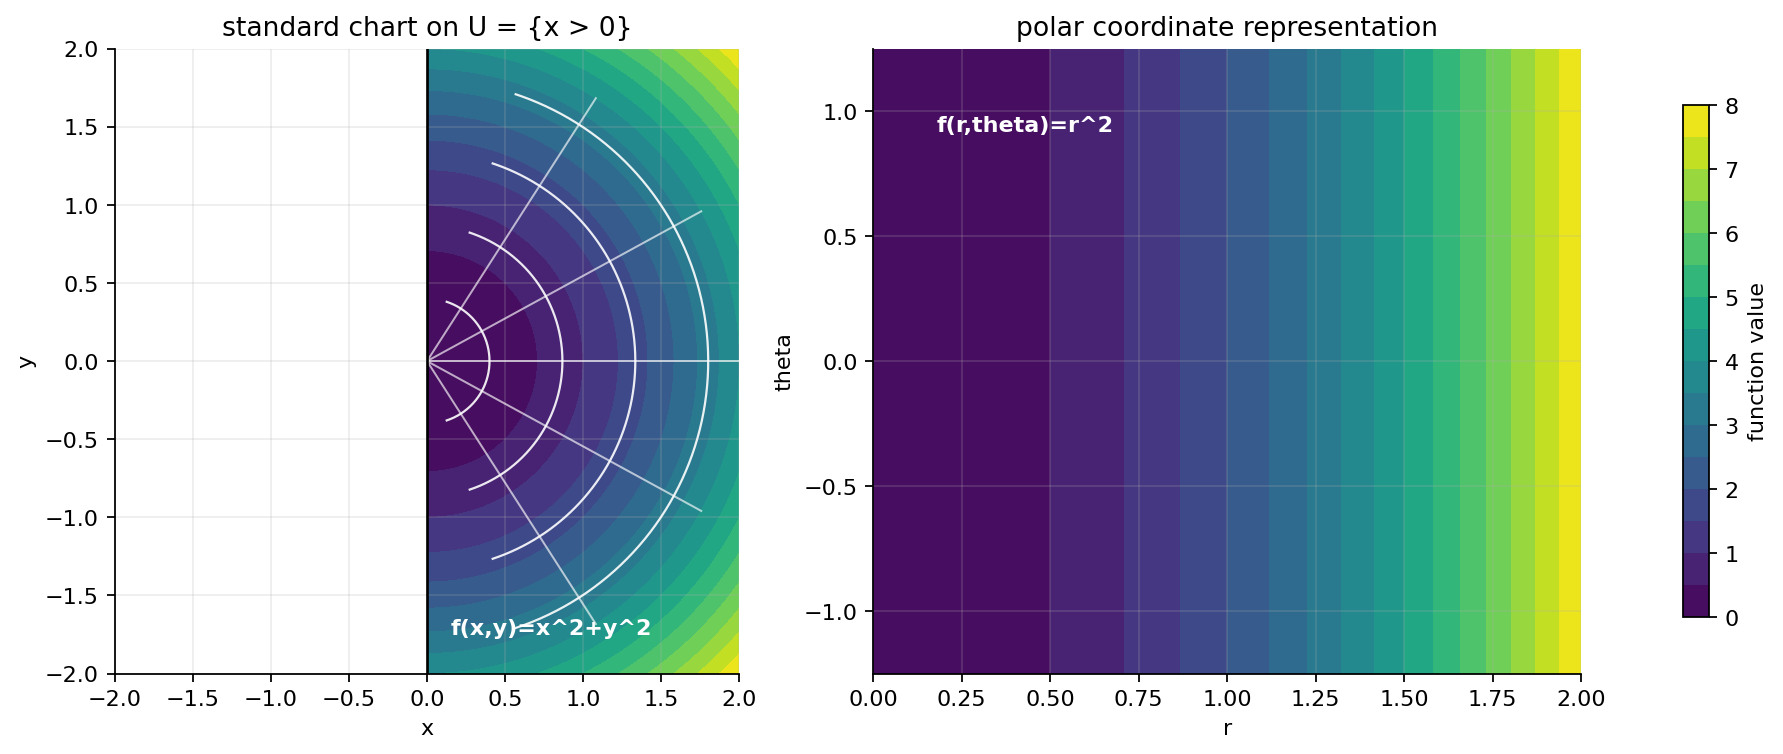

In [2]:
x_sym, y_sym, r_sym, theta_sym = sp.symbols("x y r theta", real=True)
polar_identity = sp.simplify(
    (r_sym * sp.cos(theta_sym)) ** 2
    + (r_sym * sp.sin(theta_sym)) ** 2
    - r_sym ** 2
)
theta_derivative = sp.diff(r_sym ** 2, theta_sym)

grid = np.linspace(-2.0, 2.0, 260)
X, Y = np.meshgrid(grid, grid)
Z = X**2 + Y**2
Z = np.ma.masked_where(X <= 0, Z)

R = np.linspace(0.0, 2.0, 220)
T = np.linspace(-1.25, 1.25, 220)
RR, TT = np.meshgrid(R, T)
polar_Z = RR**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
ax = axes[0]
contour = ax.contourf(X, Y, Z, levels=18, cmap="viridis")
for rr in np.linspace(0.4, 1.8, 4):
    th = np.linspace(-1.25, 1.25, 240)
    ax.plot(rr * np.cos(th), rr * np.sin(th), color="white", lw=1.0, alpha=0.9)
for th in np.linspace(-1.0, 1.0, 5):
    rr = np.linspace(0.0, 2.0, 120)
    ax.plot(rr * np.cos(th), rr * np.sin(th), color="white", lw=0.9, alpha=0.65)
ax.axvline(0, color="black", lw=1.2)
ax.set_title("standard chart on U = {x > 0}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.text(0.15, -1.75, "f(x,y)=x^2+y^2", color="white", weight="bold")

ax = axes[1]
ax.contourf(RR, TT, polar_Z, levels=18, cmap="viridis")
ax.set_title("polar coordinate representation")
ax.set_xlabel("r")
ax.set_ylabel("theta")
ax.text(0.18, 0.92, "f(r,theta)=r^2", color="white", weight="bold")
fig.colorbar(contour, ax=axes, shrink=0.82, label="function value")

coordinate_path = save_matplotlib(fig, FIGURES / "coordinate-representation-polar-function.png")
plt.close(fig)
ARTIFACTS.append(coordinate_path)
CHECK_REPORT["coordinate_function"] = {
    "polar_identity_zero": bool(polar_identity == 0),
    "theta_derivative": str(theta_derivative),
    "chart_domain": "right half-plane x > 0, with polar theta in (-pi/2, pi/2)",
}
display_artifact(coordinate_path, width=860)


## Smooth Maps: The Coordinate Square

For maps between manifolds there are two chart translations: one on the source and one on the target. The map is smooth near `p` when the coordinate expression `psi o F o phi^{-1}` is ordinary smooth. The target chart condition is part of the definition because otherwise a discontinuous map can be made to look harmless on fragments.

The example here is `epsilon(t) = exp(2*pi*i*t)`, viewed as a map from `R` to the circle. Around any point of the circle that avoids the chart cut, an angle chart unwraps a small arc, and the coordinate expression is linear in `t`.


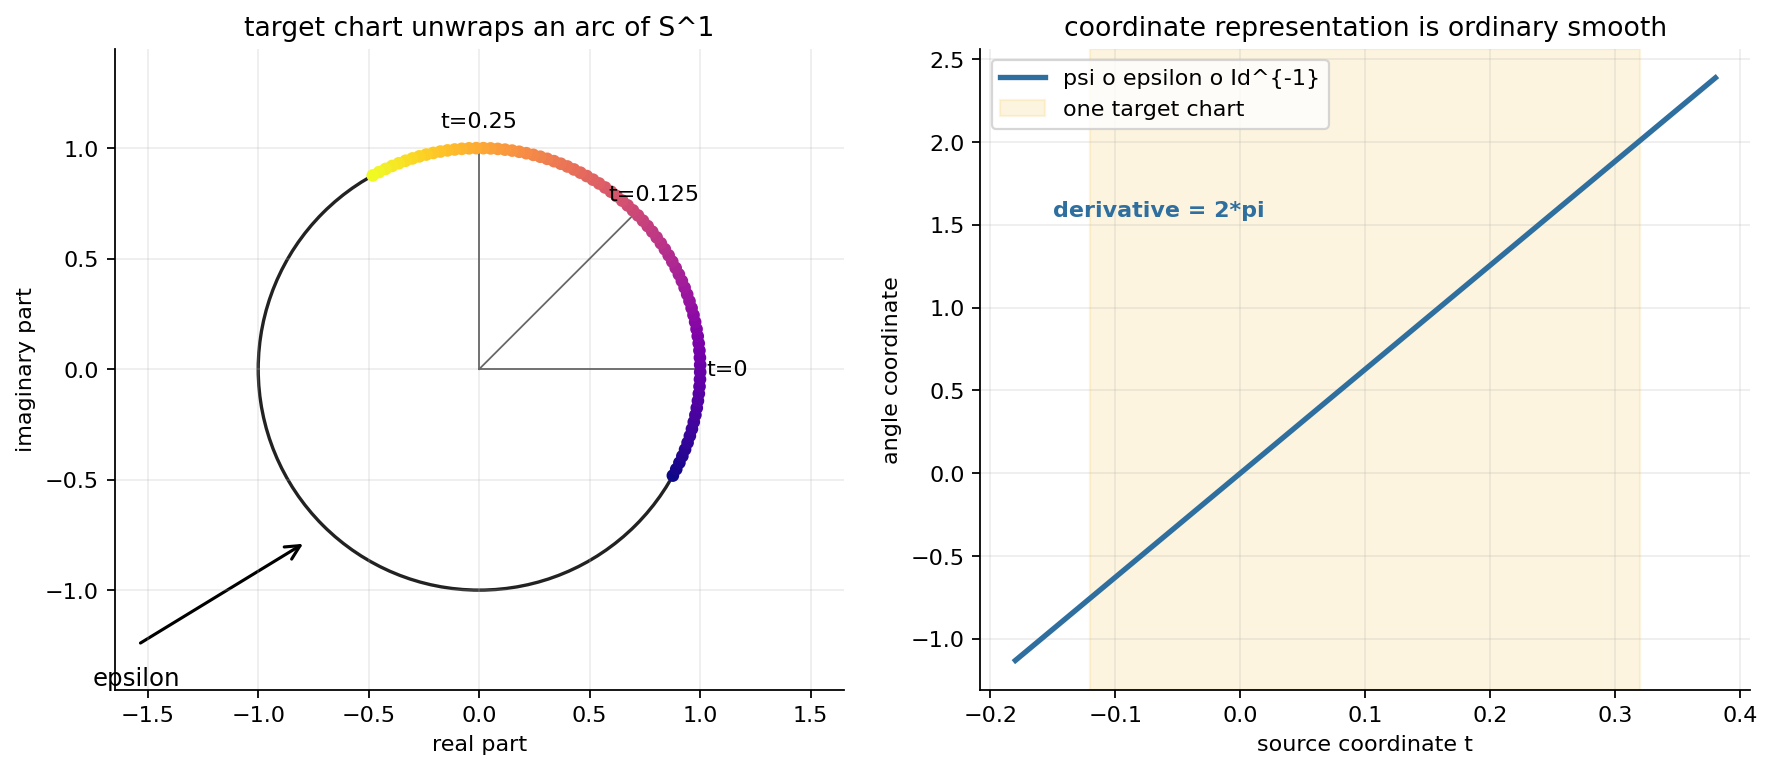

In [3]:
t_sym = sp.symbols("t", real=True)
circle_residual = sp.simplify(sp.cos(2 * sp.pi * t_sym) ** 2 + sp.sin(2 * sp.pi * t_sym) ** 2 - 1)
angle_coordinate_derivative = sp.diff(2 * sp.pi * t_sym, t_sym)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7), constrained_layout=True)
ax = axes[0]
circle = Circle((0, 0), 1, fill=False, color="#222222", lw=1.5)
ax.add_patch(circle)
sample_t = np.linspace(-0.08, 0.33, 80)
pts = np.column_stack([np.cos(2 * np.pi * sample_t), np.sin(2 * np.pi * sample_t)])
ax.scatter(pts[:, 0], pts[:, 1], c=sample_t, cmap="plasma", s=22, zorder=3)
for value in [0.0, 0.125, 0.25]:
    point = (np.cos(2 * np.pi * value), np.sin(2 * np.pi * value))
    ax.plot([0, point[0]], [0, point[1]], color="#666666", lw=0.8)
    ax.text(point[0] * 1.12, point[1] * 1.12, f"t={value:g}", ha="center", va="center")
ax.add_patch(FancyArrowPatch((-1.55, -1.25), (-0.78, -0.78), arrowstyle="->", mutation_scale=16, lw=1.4))
ax.text(-1.75, -1.43, "epsilon", fontsize=11)
ax.set_title("target chart unwraps an arc of S^1")
ax.set_aspect("equal")
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.45, 1.45)
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")

ax = axes[1]
local_t = np.linspace(-0.18, 0.38, 220)
angle = 2 * np.pi * local_t
ax.plot(local_t, angle, color="#2f6f9f", lw=2.4, label="psi o epsilon o Id^{-1}")
ax.axvspan(-0.12, 0.32, color="#f2d16b", alpha=0.22, label="one target chart")
ax.set_title("coordinate representation is ordinary smooth")
ax.set_xlabel("source coordinate t")
ax.set_ylabel("angle coordinate")
ax.legend(loc="upper left")
ax.text(-0.15, 1.55, "derivative = 2*pi", color="#2f6f9f", weight="bold")

smooth_map_path = save_matplotlib(fig, FIGURES / "smooth-map-coordinate-square.png")
plt.close(fig)
ARTIFACTS.append(smooth_map_path)
CHECK_REPORT["smooth_map_coordinate_square"] = {
    "circle_residual_zero": bool(circle_residual == 0),
    "angle_coordinate_derivative": str(angle_coordinate_derivative),
    "target_chart_condition": "the highlighted arc avoids the cut of an angle chart",
}
display_artifact(smooth_map_path, width=860)


## Local Smoothness Tests and Failure Modes

The source chapter emphasizes that smoothness is local, but not in a careless way. The map must land in a target chart near the point, and the final map must be continuous. Two useful warnings are visible below.

- A step function can be made to look locally constant on the two sides of the jump if the target-chart landing condition is weakened, but the map is not continuous.
- Smooth definitions on closed half-lines that agree at a point do not necessarily glue to a smooth global function. The function `abs(x)` is the standard cusp.


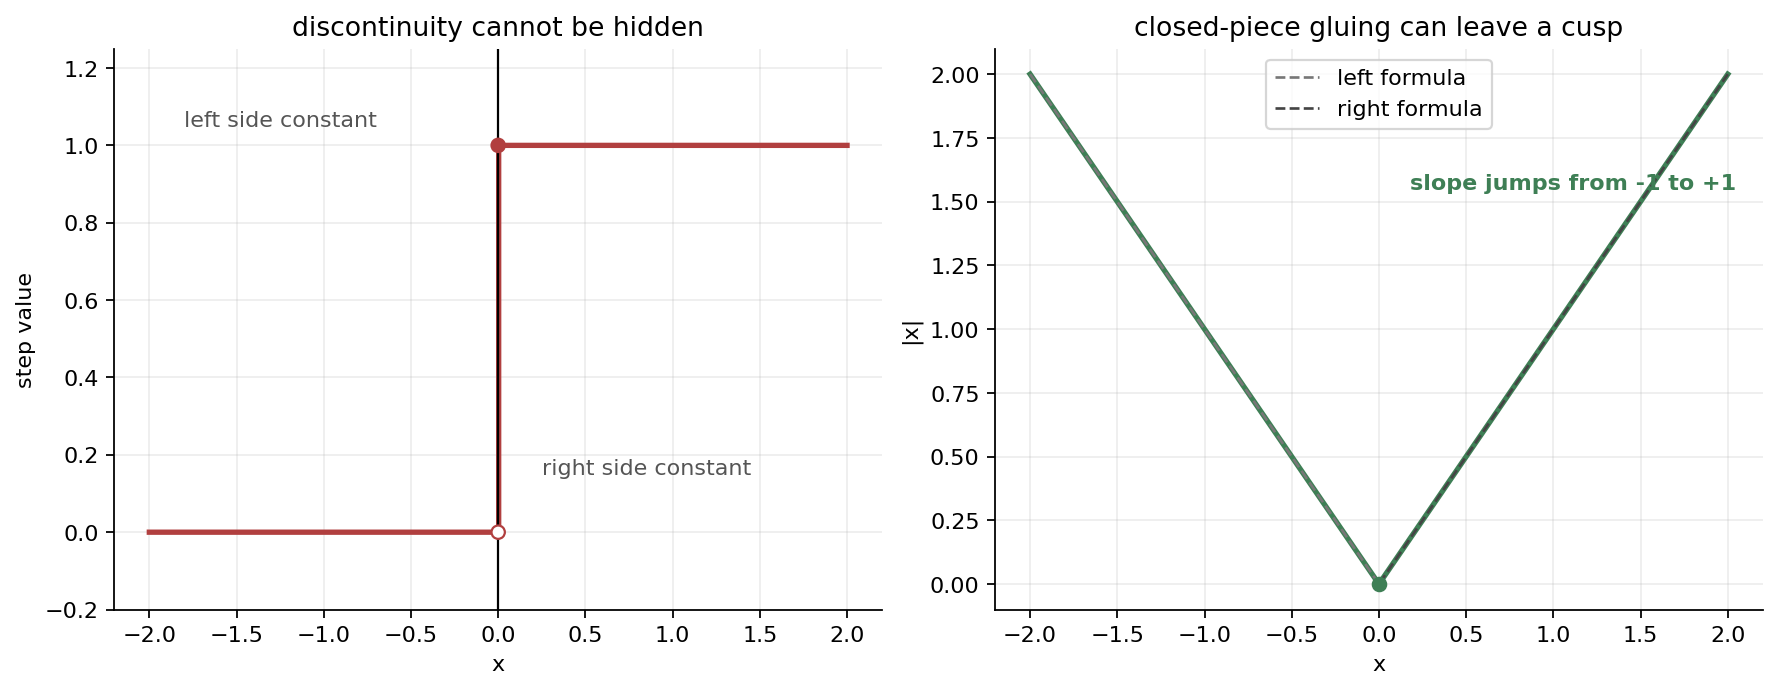

In [4]:
xs = np.linspace(-2.0, 2.0, 700)
step = np.where(xs >= 0, 1.0, 0.0)
abs_values = np.abs(xs)

left_slope = -1.0
right_slope = 1.0
derivative_jump = right_slope - left_slope

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
ax = axes[0]
ax.step(xs, step, where="post", color="#b13f3f", lw=2.4)
ax.scatter([0, 0], [0, 1], color=["white", "#b13f3f"], edgecolor="#b13f3f", zorder=5)
ax.axvline(0, color="black", lw=1.0)
ax.set_ylim(-0.2, 1.25)
ax.set_title("discontinuity cannot be hidden")
ax.set_xlabel("x")
ax.set_ylabel("step value")
ax.text(-1.8, 1.05, "left side constant", color="#555555")
ax.text(0.25, 0.15, "right side constant", color="#555555")

ax = axes[1]
ax.plot(xs, abs_values, color="#3e7f55", lw=2.4)
ax.plot(xs[xs <= 0], -xs[xs <= 0], "--", color="#777777", lw=1.2, label="left formula")
ax.plot(xs[xs >= 0], xs[xs >= 0], "--", color="#444444", lw=1.2, label="right formula")
ax.scatter([0], [0], color="#3e7f55", zorder=5)
ax.set_title("closed-piece gluing can leave a cusp")
ax.set_xlabel("x")
ax.set_ylabel("|x|")
ax.legend(loc="upper center")
ax.text(0.18, 1.55, "slope jumps from -1 to +1", color="#3e7f55", weight="bold")

failure_path = save_matplotlib(fig, FIGURES / "local-test-failure-modes.png")
plt.close(fig)
ARTIFACTS.append(failure_path)
CHECK_REPORT["failure_modes"] = {
    "step_jump_at_zero": 1.0,
    "abs_left_derivative": left_slope,
    "abs_right_derivative": right_slope,
    "abs_derivative_jump": derivative_jump,
}
display_artifact(failure_path, width=860)


## Diffeomorphisms: Smooth Sameness

A diffeomorphism is a bijective smooth map whose inverse is smooth. The radial map

`F(x) = x / sqrt(1 - |x|^2)`

sends the open unit ball onto the whole plane; its inverse is

`G(y) = y / sqrt(1 + |y|^2)`.

The grid image shows why the boundary of the ball is not part of the domain: radii near `1` are pushed far outward. The computation checks that `G(F(x)) = x` and `F(G(y)) = y` on samples, and symbolically in the radial coordinate.


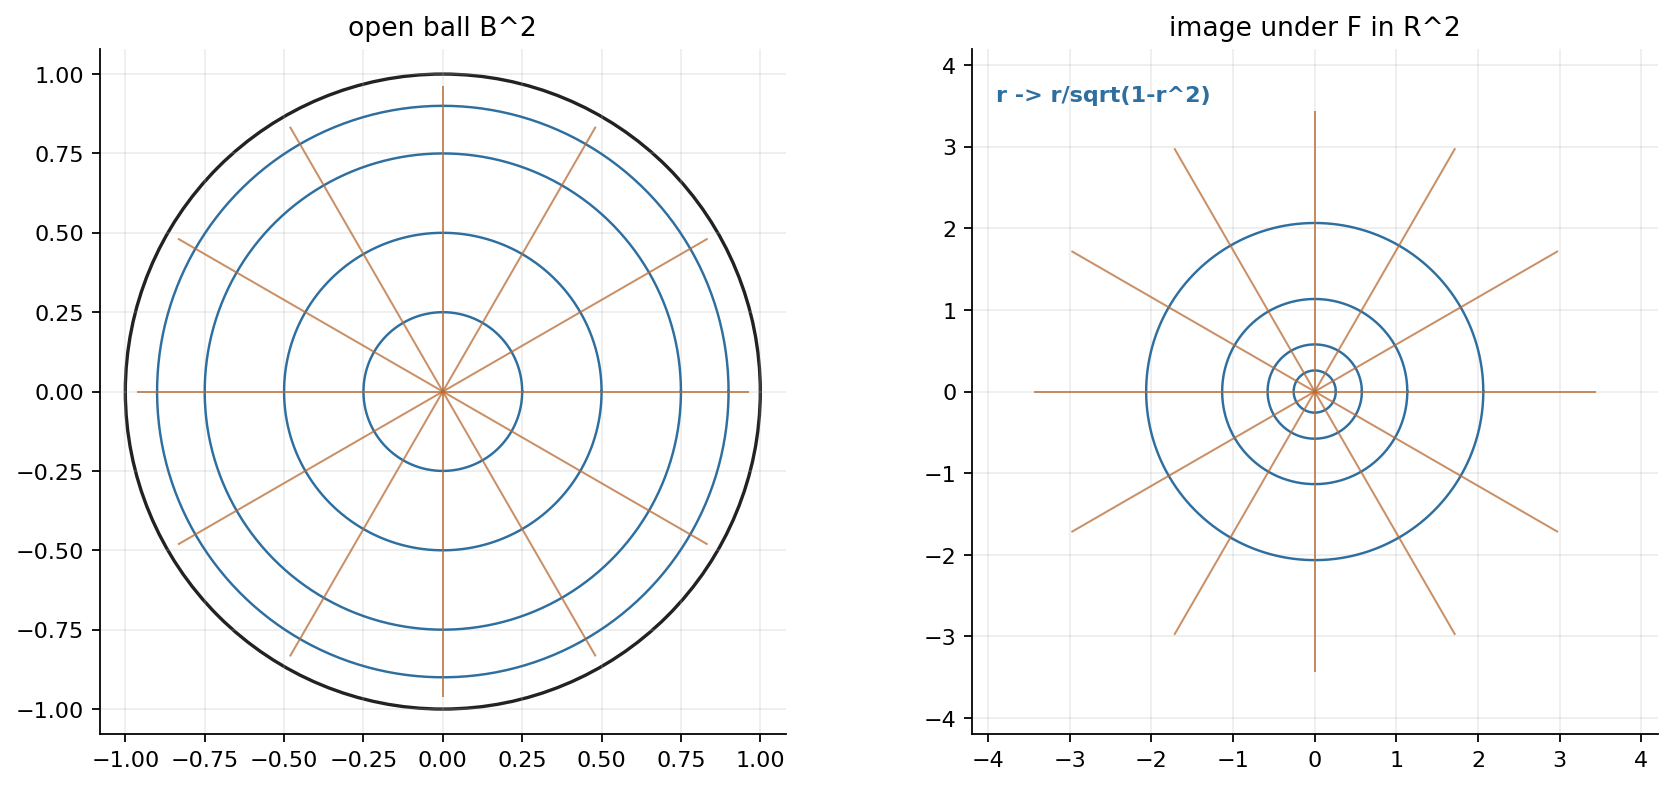

In [5]:
rho = sp.symbols("rho", nonnegative=True)
radial_F = rho / sp.sqrt(1 - rho**2)
radial_G_after_F = sp.simplify(radial_F / sp.sqrt(1 + radial_F**2))

rng = np.random.default_rng(22)
angles = rng.uniform(0, 2 * np.pi, 200)
radii = np.sqrt(rng.uniform(0, 0.92**2, 200))
ball_points = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])

def F_ball(points):
    norm_sq = np.sum(points**2, axis=1, keepdims=True)
    return points / np.sqrt(1 - norm_sq)

def G_plane(points):
    norm_sq = np.sum(points**2, axis=1, keepdims=True)
    return points / np.sqrt(1 + norm_sq)

plane_points = F_ball(ball_points)
back_to_ball = G_plane(plane_points)
inverse_error = float(np.max(np.linalg.norm(back_to_ball - ball_points, axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
radii_grid = [0.25, 0.5, 0.75, 0.9]
theta_grid = np.linspace(0, 2 * np.pi, 360)
ray_angles = np.linspace(0, 2 * np.pi, 12, endpoint=False)

ax = axes[0]
ax.add_patch(Circle((0, 0), 1, fill=False, color="#222222", lw=1.5))
for rr in radii_grid:
    ax.plot(rr * np.cos(theta_grid), rr * np.sin(theta_grid), color="#2f6f9f", lw=1.1)
for th in ray_angles:
    rr = np.linspace(0, 0.96, 100)
    ax.plot(rr * np.cos(th), rr * np.sin(th), color="#b86b34", lw=0.9, alpha=0.75)
ax.set_title("open ball B^2")
ax.set_aspect("equal")
ax.set_xlim(-1.08, 1.08)
ax.set_ylim(-1.08, 1.08)

ax = axes[1]
for rr in radii_grid:
    mapped = rr / np.sqrt(1 - rr**2)
    ax.plot(mapped * np.cos(theta_grid), mapped * np.sin(theta_grid), color="#2f6f9f", lw=1.1)
for th in ray_angles:
    rr = np.linspace(0, 0.96, 160)
    mapped = rr / np.sqrt(1 - rr**2)
    ax.plot(mapped * np.cos(th), mapped * np.sin(th), color="#b86b34", lw=0.9, alpha=0.75)
ax.set_title("image under F in R^2")
ax.set_aspect("equal")
ax.set_xlim(-4.2, 4.2)
ax.set_ylim(-4.2, 4.2)
ax.text(-3.9, 3.55, "r -> r/sqrt(1-r^2)", weight="bold", color="#2f6f9f")

diffeo_path = save_matplotlib(fig, FIGURES / "diffeomorphism-ball-plane-radial.png")
plt.close(fig)
ARTIFACTS.append(diffeo_path)
CHECK_REPORT["diffeomorphism_ball_plane"] = {
    "symbolic_radial_G_after_F_minus_r": str(sp.simplify(radial_G_after_F - rho)),
    "sample_inverse_error": inverse_error,
    "sample_count": int(len(ball_points)),
}
display_artifact(diffeo_path, width=860)


## Cutoff and Bump Functions

Partitions of unity depend on a special smooth trick: a function can be zero on one side and positive on the other while still having every derivative vanish at the joining point. From that flat function we build a cutoff, and from a cutoff we build a radial bump supported inside a coordinate ball.

Inspect the three panels: the first function is flat at `0`, the second transitions from `1` to `0`, and the third is a radial bump with a visible support boundary.


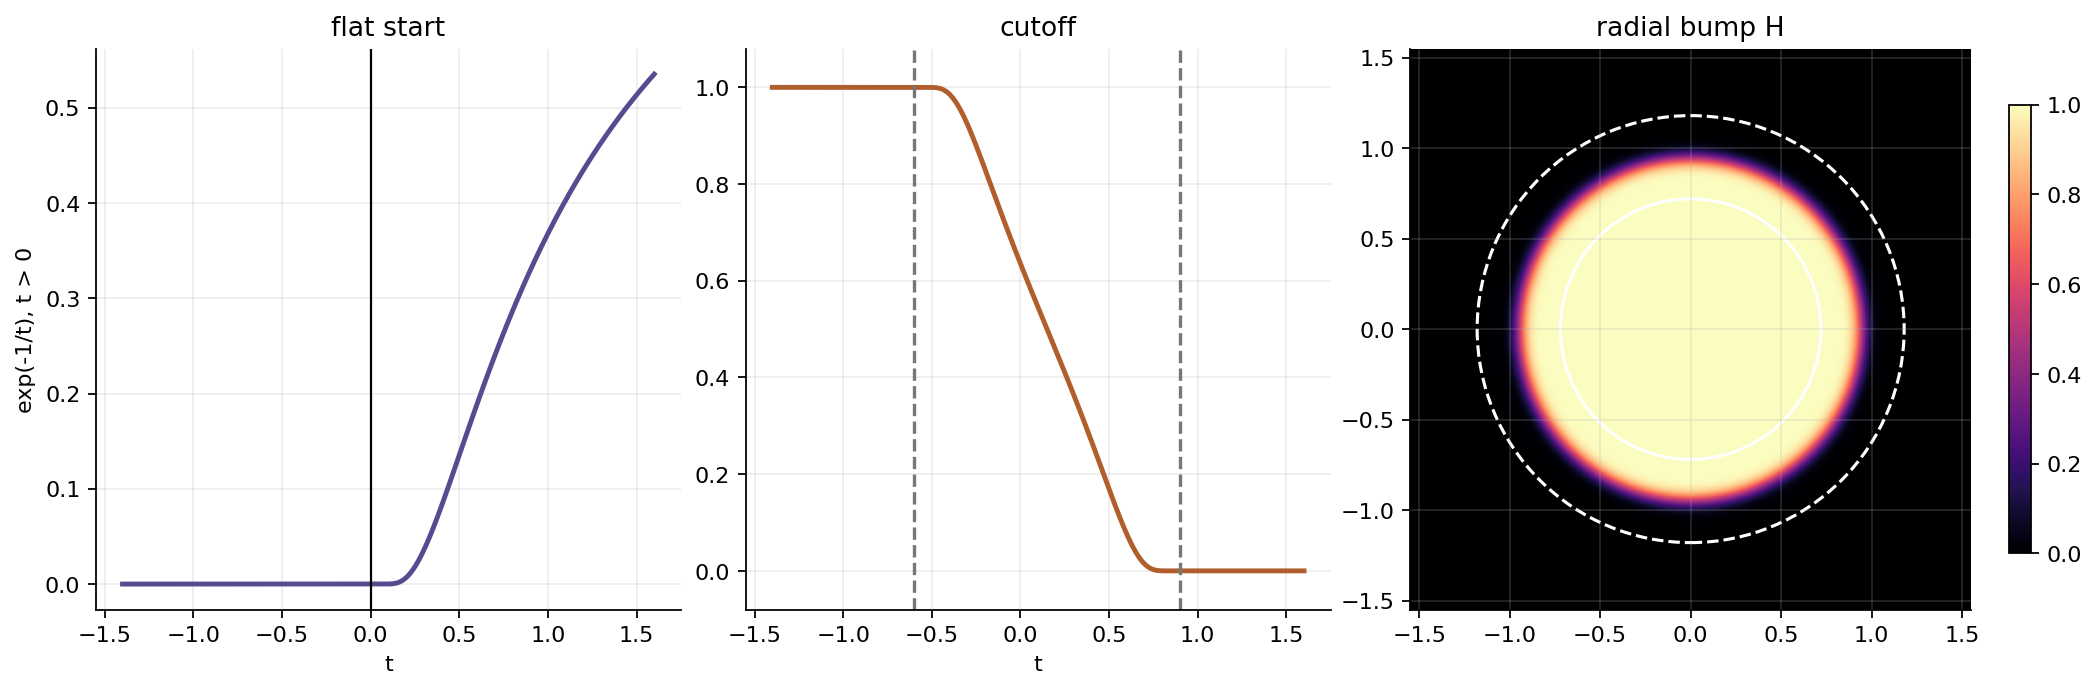

In [6]:
def flat_positive(t):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    mask = t > 0
    out[mask] = np.exp(-1.0 / t[mask])
    return out

def cutoff(t, r1=-0.8, r2=0.8):
    t = np.asarray(t, dtype=float)
    numerator = flat_positive(r2 - t)
    denominator = numerator + flat_positive(t - r1)
    return numerator / denominator

t_values = np.linspace(-1.4, 1.6, 600)
flat_values = flat_positive(t_values)
cutoff_values = cutoff(t_values, -0.6, 0.9)

grid2 = np.linspace(-1.55, 1.55, 260)
X2, Y2 = np.meshgrid(grid2, grid2)
radius = np.sqrt(X2**2 + Y2**2)
H = cutoff(radius, 0.72, 1.18)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)
axes[0].plot(t_values, flat_values, color="#574b90", lw=2.2)
axes[0].axvline(0, color="black", lw=1.0)
axes[0].set_title("flat start")
axes[0].set_xlabel("t")
axes[0].set_ylabel("exp(-1/t), t > 0")

axes[1].plot(t_values, cutoff_values, color="#b05f2c", lw=2.2)
axes[1].axvline(-0.6, color="#777777", ls="--")
axes[1].axvline(0.9, color="#777777", ls="--")
axes[1].set_title("cutoff")
axes[1].set_xlabel("t")
axes[1].set_ylim(-0.08, 1.08)

im = axes[2].imshow(H, extent=[grid2.min(), grid2.max(), grid2.min(), grid2.max()], origin="lower", cmap="magma")
axes[2].add_patch(Circle((0, 0), 0.72, fill=False, color="white", lw=1.4))
axes[2].add_patch(Circle((0, 0), 1.18, fill=False, color="white", lw=1.4, ls="--"))
axes[2].set_title("radial bump H")
axes[2].set_aspect("equal")
fig.colorbar(im, ax=axes[2], shrink=0.8)

bump_path = save_matplotlib(fig, FIGURES / "cutoff-bump-functions.png")
plt.close(fig)
ARTIFACTS.append(bump_path)

small_ts = np.array([0.04, 0.03, 0.02])
flat_ratios = {
    f"t={float(tt):.2f}, k={k}": float(np.exp(-1.0 / tt) / (tt**k))
    for tt in small_ts
    for k in [1, 2, 3]
}
CHECK_REPORT["cutoff_bump"] = {
    "cutoff_min": float(cutoff_values.min()),
    "cutoff_max": float(cutoff_values.max()),
    "radial_bump_inside_core_min": float(H[radius <= 0.70].min()),
    "radial_bump_outside_support_max": float(H[radius >= 1.20].max()),
    "flat_ratios_near_zero": flat_ratios,
}
display_artifact(bump_path, width=940)


## Partitions of Unity: Normalize Local Bumps

The theorem for partitions of unity has a practical recipe:

1. Choose a locally finite refinement by coordinate balls.
2. Put a bump inside each refined set.
3. Add all the bumps. Local finiteness makes the sum finite near each point.
4. Divide each bump by the positive total.
5. Reindex the normalized functions by the original open cover.

The next construction uses three bumps on a line segment. The proof in a manifold uses countably many coordinate balls, but the support and normalization logic is already visible here.


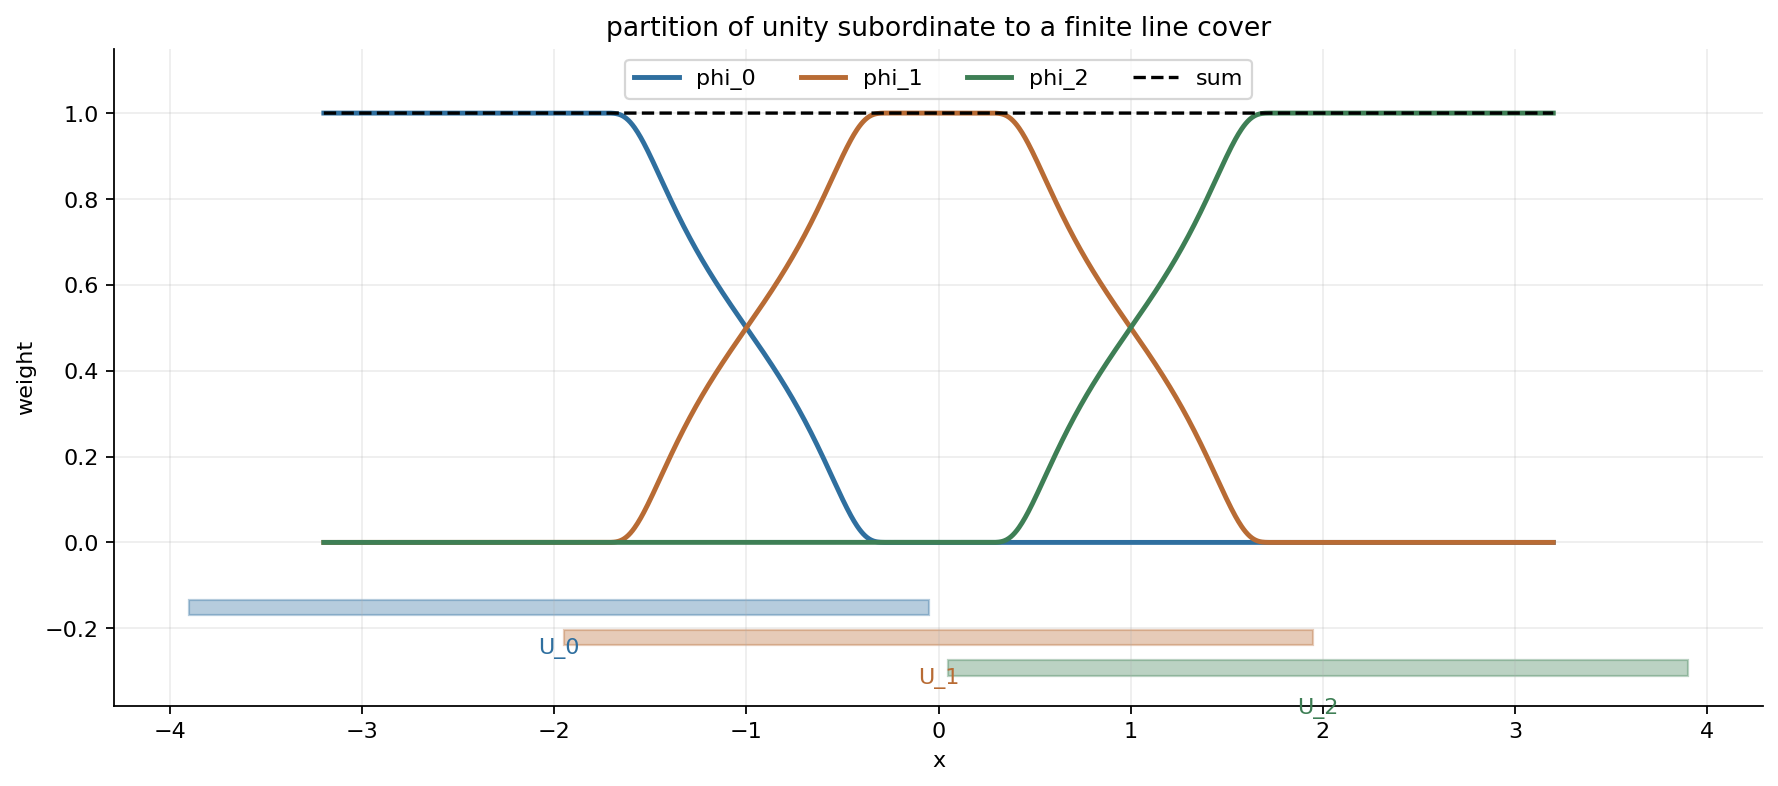

In [7]:
def compact_bump(z):
    z = np.asarray(z, dtype=float)
    out = np.zeros_like(z)
    mask = np.abs(z) < 1
    out[mask] = np.exp(-1.0 / (1.0 - z[mask] ** 2))
    return out

line = np.linspace(-3.2, 3.2, 1200)
centers = np.array([-2.0, 0.0, 2.0])
support_radius = 1.8
raw = np.vstack([compact_bump((line - c) / support_radius) for c in centers])
total = raw.sum(axis=0)
weights = raw / total
cover_intervals = [(-3.9, -0.05), (-1.95, 1.95), (0.05, 3.9)]

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
colors = ["#2f6f9f", "#b86b34", "#3e7f55"]
for i, (weight, color) in enumerate(zip(weights, colors)):
    ax.plot(line, weight, color=color, lw=2.2, label=f"phi_{i}")
    left, right = cover_intervals[i]
    ax.add_patch(Rectangle((left, -0.17 - 0.07 * i), right - left, 0.035, color=color, alpha=0.35, clip_on=False))
    ax.text((left + right) / 2, -0.22 - 0.07 * i, f"U_{i}", ha="center", va="top", color=color)
ax.plot(line, weights.sum(axis=0), color="black", ls="--", lw=1.5, label="sum")
ax.set_ylim(-0.38, 1.15)
ax.set_title("partition of unity subordinate to a finite line cover")
ax.set_xlabel("x")
ax.set_ylabel("weight")
ax.legend(ncol=4, loc="upper center")

partition_path = save_matplotlib(fig, FIGURES / "partition-of-unity-line-cover.png")
plt.close(fig)
ARTIFACTS.append(partition_path)

support_ranges = []
support_contained = True
for i, c in enumerate(centers):
    theoretical = (float(c - support_radius), float(c + support_radius))
    support_ranges.append(theoretical)
    left, right = cover_intervals[i]
    support_contained = support_contained and (left < theoretical[0] and theoretical[1] < right)

CHECK_REPORT["partition_of_unity"] = {
    "sum_one_max_error": float(np.max(np.abs(weights.sum(axis=0) - 1.0))),
    "nonnegative": bool(np.all(weights >= 0)),
    "support_ranges": support_ranges,
    "support_contained_in_cover": bool(support_contained),
    "max_simultaneous_nonzero_weights_on_grid": int(np.max((raw > 1e-12).sum(axis=0))),
    "positive_denominator_min": float(total.min()),
}
display_artifact(partition_path, width=860)


## Proof View: Where the Partition Theorem Gets Its Power

The proof is not just a formula. It is a chain of guarantees: paracompactness supplies local finiteness; regular coordinate balls supply room for bump supports; local finiteness makes the sum smooth; positivity makes normalization legal; reindexing returns to the original open cover.


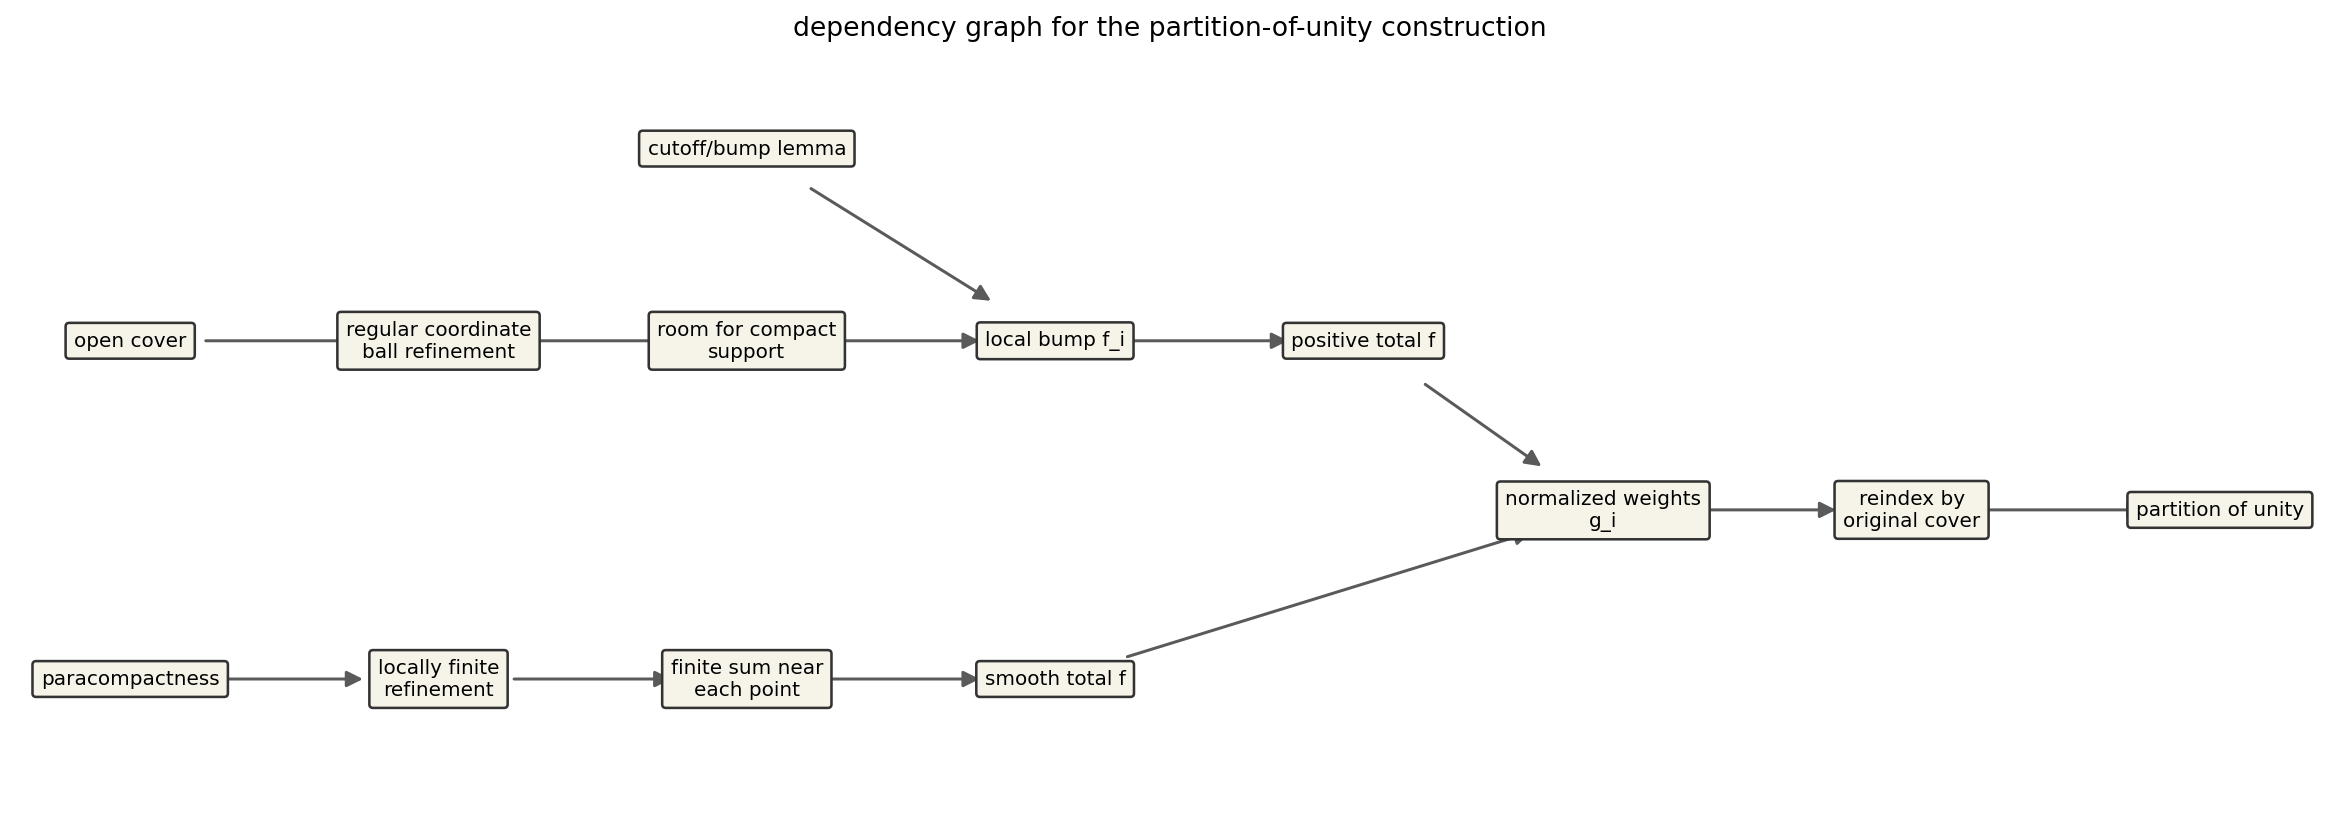

In [8]:
import textwrap

G = nx.DiGraph()
proof_edges = [
    ("open cover", "regular coordinate ball refinement"),
    ("paracompactness", "locally finite refinement"),
    ("regular coordinate ball refinement", "room for compact support"),
    ("cutoff/bump lemma", "local bump f_i"),
    ("room for compact support", "local bump f_i"),
    ("locally finite refinement", "finite sum near each point"),
    ("local bump f_i", "positive total f"),
    ("finite sum near each point", "smooth total f"),
    ("positive total f", "normalized weights g_i"),
    ("smooth total f", "normalized weights g_i"),
    ("normalized weights g_i", "reindex by original cover"),
    ("reindex by original cover", "partition of unity"),
]
G.add_edges_from(proof_edges)
pos = {
    "open cover": (0.0, 2.2),
    "regular coordinate ball refinement": (2.7, 2.2),
    "room for compact support": (5.4, 2.2),
    "cutoff/bump lemma": (5.4, 3.45),
    "local bump f_i": (8.1, 2.2),
    "positive total f": (10.8, 2.2),
    "paracompactness": (0.0, 0.0),
    "locally finite refinement": (2.7, 0.0),
    "finite sum near each point": (5.4, 0.0),
    "smooth total f": (8.1, 0.0),
    "normalized weights g_i": (12.9, 1.1),
    "reindex by original cover": (15.6, 1.1),
    "partition of unity": (18.3, 1.1),
}

fig, ax = plt.subplots(figsize=(14.5, 5.0), constrained_layout=True)
for start, end in proof_edges:
    ax.annotate(
        "",
        xy=pos[end],
        xytext=pos[start],
        arrowprops={
            "arrowstyle": "-|>",
            "lw": 1.35,
            "color": "#5a5a5a",
            "shrinkA": 34,
            "shrinkB": 34,
            "mutation_scale": 15,
        },
    )
for node, (px, py) in pos.items():
    ax.text(
        px,
        py,
        textwrap.fill(node, width=18),
        ha="center",
        va="center",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.42,rounding_size=0.18",
            "facecolor": "#f6f3e8",
            "edgecolor": "#333333",
            "linewidth": 1.15,
        },
    )
ax.set_title("dependency graph for the partition-of-unity construction")
ax.set_xlim(-1.0, 19.2)
ax.set_ylim(-0.8, 4.1)
ax.axis("off")

proof_path = save_matplotlib(fig, FIGURES / "partition-proof-dependency-graph.png")
plt.close(fig)
ARTIFACTS.append(proof_path)
CHECK_REPORT["partition_proof_graph"] = {
    "is_directed_acyclic_graph": bool(nx.is_directed_acyclic_graph(G)),
    "node_count": int(G.number_of_nodes()),
    "edge_count": int(G.number_of_edges()),
    "terminal_node": "partition of unity",
}
display_artifact(proof_path, width=940)


## Local-to-Global: Gluing Versus Blending

There are two common strategies.

**Gluing** is rigid: the local maps already agree on overlaps, so there is a unique global map whose restrictions are the local maps.

**Blending** is flexible: local objects need not agree, but the codomain must support weighted sums or another compatible averaging operation. Partitions of unity give the weights; the hard part in later chapters is proving the blended object keeps the intended geometric property.


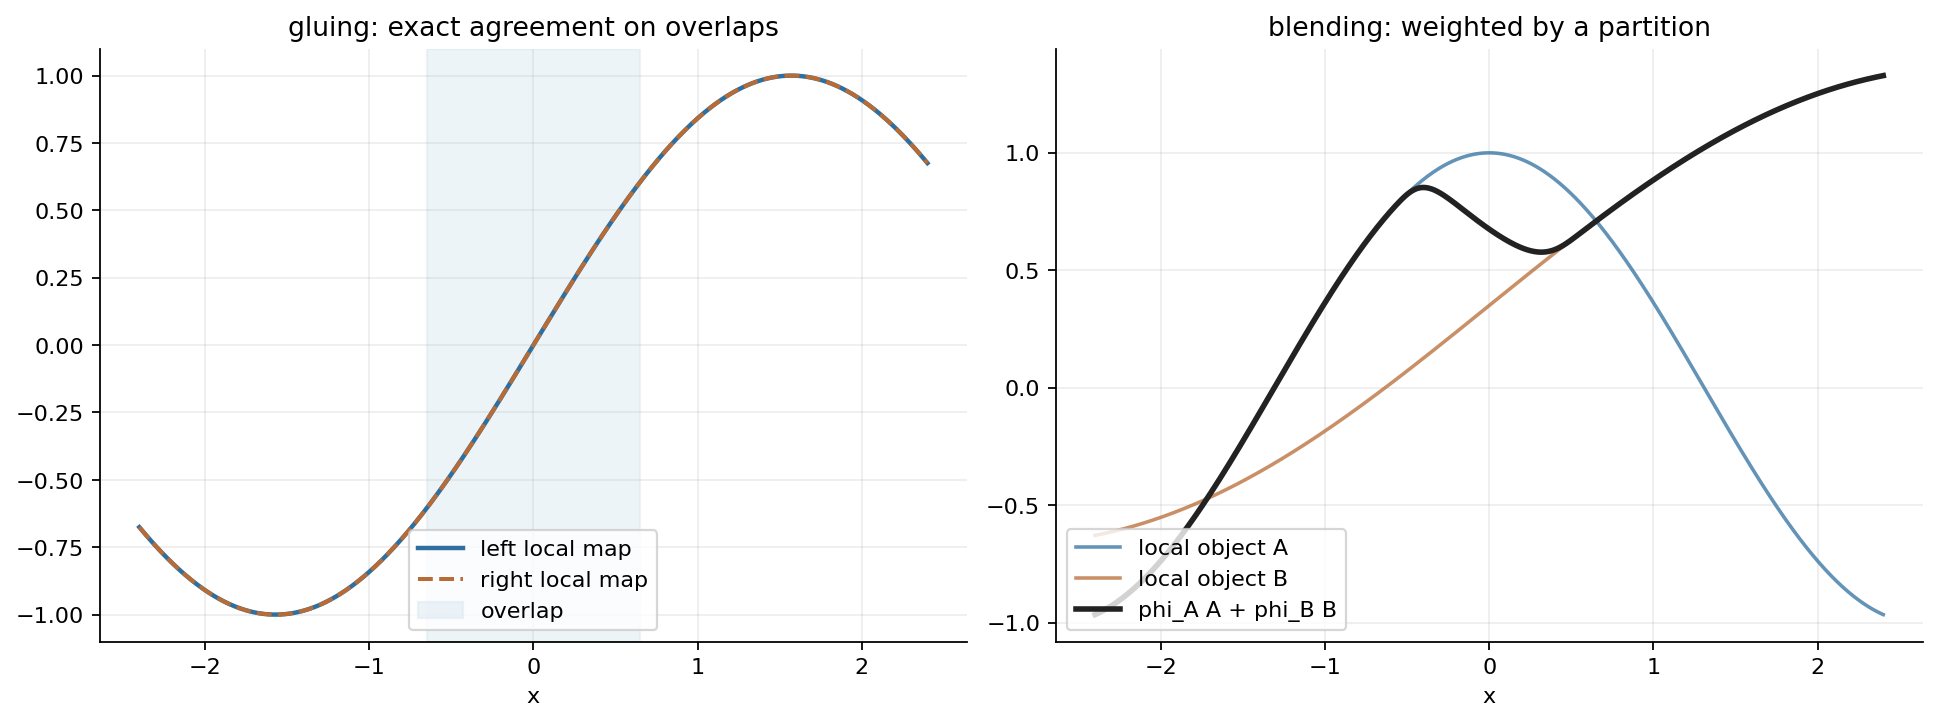

In [9]:
lab_x = np.linspace(-2.4, 2.4, 900)
exact_left = np.sin(lab_x)
exact_right = np.sin(lab_x)
overlap_mask = np.abs(lab_x) < 0.65
exact_overlap_error = float(np.max(np.abs(exact_left[overlap_mask] - exact_right[overlap_mask])))

phi_left = cutoff(lab_x, -0.65, 0.65)
phi_right = 1.0 - phi_left
local_a = np.cos(1.2 * lab_x)
local_b = 0.35 + 0.18 * lab_x + 0.55 * np.sin(0.7 * lab_x)
blended = phi_left * local_a + phi_right * local_b

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
ax = axes[0]
ax.plot(lab_x, exact_left, color="#2f6f9f", lw=2.0, label="left local map")
ax.plot(lab_x, exact_right, "--", color="#b86b34", lw=1.8, label="right local map")
ax.axvspan(-0.65, 0.65, color="#d8e7f1", alpha=0.45, label="overlap")
ax.set_title("gluing: exact agreement on overlaps")
ax.set_xlabel("x")
ax.legend(loc="lower center")

ax = axes[1]
ax.plot(lab_x, local_a, color="#2f6f9f", alpha=0.75, lw=1.6, label="local object A")
ax.plot(lab_x, local_b, color="#b86b34", alpha=0.75, lw=1.6, label="local object B")
ax.plot(lab_x, blended, color="#222222", lw=2.5, label="phi_A A + phi_B B")
ax.fill_between(lab_x, -1.35, -1.25, where=phi_left > 0.02, color="#2f6f9f", alpha=0.25, transform=ax.get_xaxis_transform())
ax.fill_between(lab_x, -1.48, -1.38, where=phi_right > 0.02, color="#b86b34", alpha=0.25, transform=ax.get_xaxis_transform())
ax.set_title("blending: weighted by a partition")
ax.set_xlabel("x")
ax.legend(loc="lower left")

gluing_path = save_matplotlib(fig, FIGURES / "gluing-vs-blending.png")
plt.close(fig)
ARTIFACTS.append(gluing_path)
CHECK_REPORT["gluing_vs_blending"] = {
    "exact_gluing_overlap_error": exact_overlap_error,
    "partition_weight_sum_error": float(np.max(np.abs(phi_left + phi_right - 1.0))),
    "blended_has_finite_sample_values": bool(np.all(np.isfinite(blended))),
}
display_artifact(gluing_path, width=900)


## Applications: Extension, Level Sets, and Exhaustion

Partitions of unity are valuable because they convert local data into global smooth functions. Three source-span applications are represented here.

- A bump-supported extension matches prescribed values on a closed set while vanishing outside a chosen open neighborhood.
- A nonnegative smooth function can have a specified closed set as its zero set; for a finite closed set a polynomial already demonstrates the mechanism.
- A positive exhaustion function has compact sublevel sets. On `R`, `x^2` is the basic model; on manifolds, partitions of unity build analogous functions from precompact local pieces.


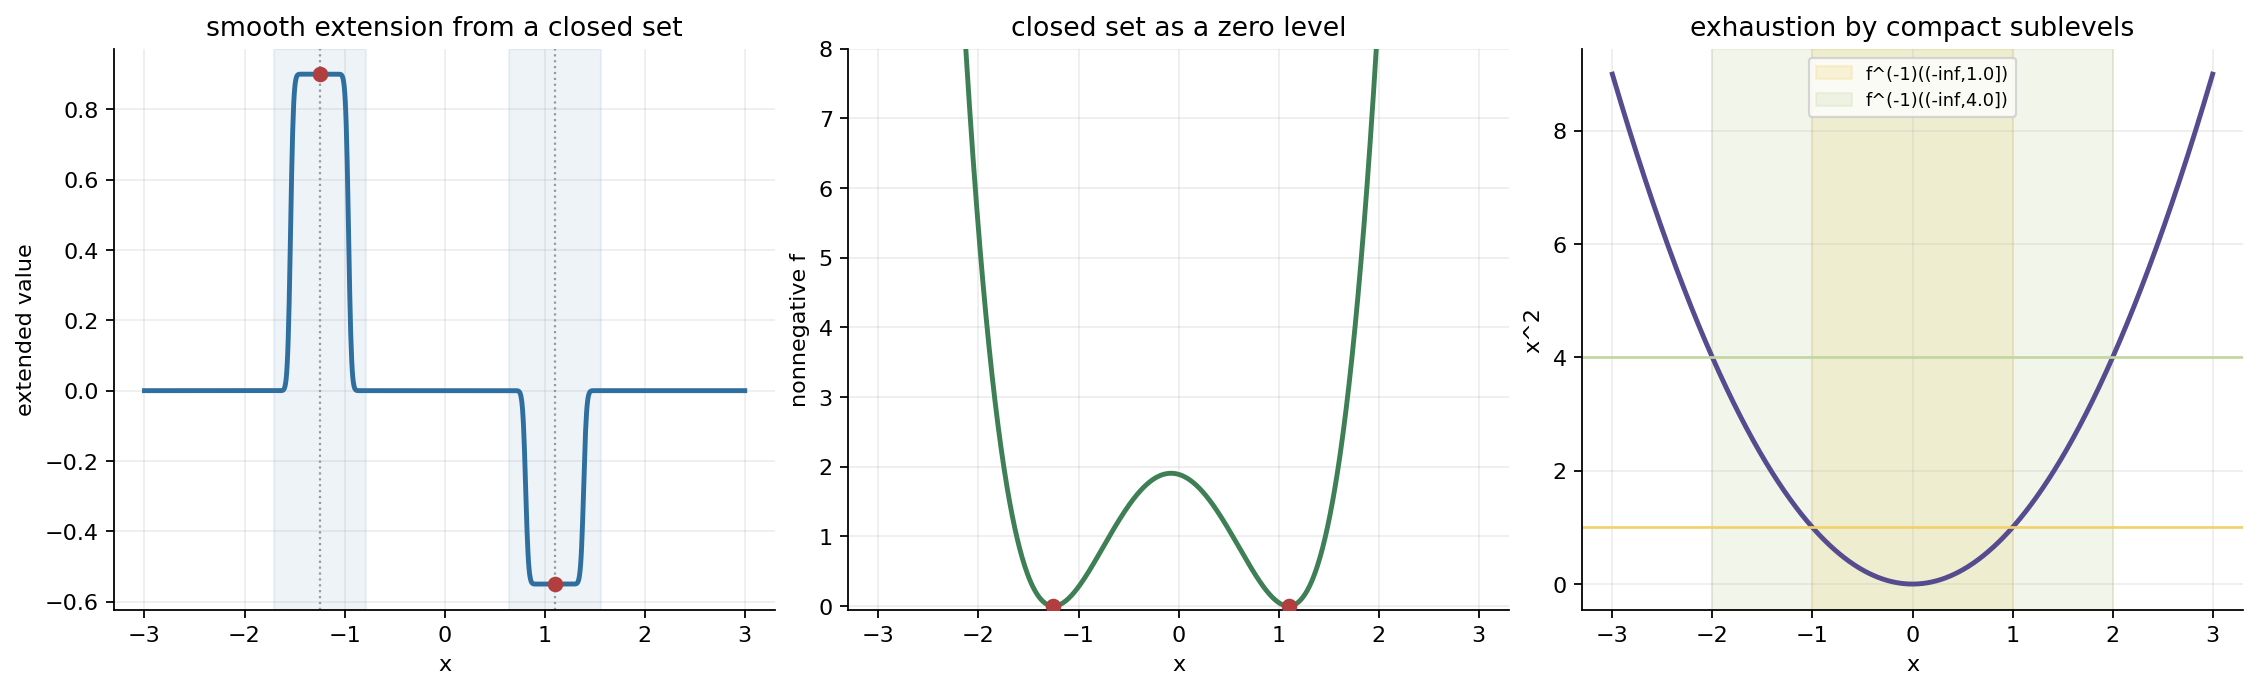

In [10]:
app_x = np.linspace(-3.0, 3.0, 1200)
closed_points = np.array([-1.25, 1.10])
prescribed_values = np.array([0.90, -0.55])
extension = np.zeros_like(app_x)
supports = []
for point, value in zip(closed_points, prescribed_values):
    bump = cutoff(np.abs(app_x - point), 0.12, 0.46)
    extension += value * bump
    supports.append((float(point - 0.46), float(point + 0.46)))

level_function = ((app_x - closed_points[0]) * (app_x - closed_points[1])) ** 2
exhaustion = app_x**2

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
ax = axes[0]
ax.plot(app_x, extension, color="#2f6f9f", lw=2.2)
for point, value in zip(closed_points, prescribed_values):
    ax.scatter([point], [value], color="#b13f3f", zorder=5)
    ax.axvline(point, color="#999999", ls=":", lw=1.0)
for left, right in supports:
    ax.axvspan(left, right, color="#2f6f9f", alpha=0.08)
ax.set_title("smooth extension from a closed set")
ax.set_xlabel("x")
ax.set_ylabel("extended value")

ax = axes[1]
ax.plot(app_x, level_function, color="#3e7f55", lw=2.2)
ax.scatter(closed_points, [0, 0], color="#b13f3f", zorder=5)
ax.set_ylim(-0.05, 8.0)
ax.set_title("closed set as a zero level")
ax.set_xlabel("x")
ax.set_ylabel("nonnegative f")

ax = axes[2]
ax.plot(app_x, exhaustion, color="#574b90", lw=2.2)
for c, color in [(1.0, "#f2d16b"), (4.0, "#c4d6a0")]:
    radius_c = math.sqrt(c)
    ax.axhline(c, color=color, lw=1.2)
    ax.axvspan(-radius_c, radius_c, color=color, alpha=0.22, label=f"f^(-1)((-inf,{c}])")
ax.set_title("exhaustion by compact sublevels")
ax.set_xlabel("x")
ax.set_ylabel("x^2")
ax.legend(loc="upper center", fontsize=8)

applications_path = save_matplotlib(fig, FIGURES / "closed-set-extension-levelset-exhaustion.png")
plt.close(fig)
ARTIFACTS.append(applications_path)

def extension_at(point):
    value = 0.0
    for center, prescribed in zip(closed_points, prescribed_values):
        value += float(prescribed * cutoff(np.array([abs(point - center)]), 0.12, 0.46)[0])
    return value

extension_errors = [
    abs(extension_at(float(point)) - float(value))
    for point, value in zip(closed_points, prescribed_values)
]
CHECK_REPORT["applications"] = {
    "closed_points": [float(v) for v in closed_points],
    "extension_value_errors_at_closed_points": [float(v) for v in extension_errors],
    "extension_support_intervals": supports,
    "level_function_zero_values": [float(((p - closed_points[0]) * (p - closed_points[1])) ** 2) for p in closed_points],
    "exhaustion_sublevel_radii": {"c=1": 1.0, "c=4": 2.0},
}
display_artifact(applications_path, width=980)


## Applied Lab

Use the cells above as a checklist for testing a new construction.

1. **Choose charts.** Identify which source and target chart domains actually contain the point and its image.
2. **Compute the coordinate expression.** Reduce the manifold statement to an ordinary function between Euclidean open sets.
3. **Check locality honestly.** If a proposed proof ignores continuity, target-chart containment, or overlap agreement, look for a step-function or cusp-type failure.
4. **When gluing is too rigid, blend.** Use a partition of unity only when the codomain operation makes weighted sums meaningful.
5. **Record support.** For partitions and extensions, the support statement is as important as smoothness.

In later chapters this lab pattern reappears for tangent-vector constructions, vector fields, forms, Riemannian metrics, and flows. The objects become richer, but the bookkeeping still starts here.


## Takeaways

- Smoothness on manifolds is ordinary smoothness after legitimate chart translation.
- The definition for maps includes a target-chart landing condition; this is what makes smooth maps continuous.
- Smoothness is local on open neighborhoods, and exactly agreeing local maps glue uniquely.
- Diffeomorphisms preserve the smooth structure, including dimension and boundary behavior.
- Cutoff and bump functions are the analytic engine behind partitions of unity.
- Partitions of unity convert local constructions into global smooth objects while controlling support.
- Extension, exhaustion, and closed-set level functions are first demonstrations of how powerful local-to-global smooth construction can be.


In [11]:
checks_path = save_json(CHECK_REPORT, CHECKS / "coordinate-and-smoothness-checks.json")
ARTIFACTS.append(checks_path)
assert_artifacts(ARTIFACTS, min_bytes=128)

from PIL import Image, ImageStat

image_summaries = []
for path in ARTIFACTS:
    if path.suffix.lower() == ".png":
        with Image.open(path) as image:
            image.load()
            stat = ImageStat.Stat(image.convert("RGB"))
            width, height = image.size
        summary = {
            "path": path.relative_to(BOOK_ROOT).as_posix(),
            "width": int(width),
            "height": int(height),
            "bytes": int(path.stat().st_size),
            "max_channel_stddev": float(max(stat.stddev)),
        }
        assert summary["width"] >= 64 and summary["height"] >= 64
        assert summary["max_channel_stddev"] > 1.0
        image_summaries.append(summary)

assert CHECK_REPORT["coordinate_function"]["polar_identity_zero"]
assert CHECK_REPORT["smooth_map_coordinate_square"]["circle_residual_zero"]
assert CHECK_REPORT["partition_of_unity"]["sum_one_max_error"] < 1e-12
assert CHECK_REPORT["partition_of_unity"]["support_contained_in_cover"]
assert CHECK_REPORT["diffeomorphism_ball_plane"]["sample_inverse_error"] < 1e-12
assert max(CHECK_REPORT["applications"]["extension_value_errors_at_closed_points"]) < 1e-12

final_sanity = {
    "status": "pass",
    "source_span_used": "printed pages 32-49; PDF pages 50-67",
    "artifact_count": len(ARTIFACTS) + 1,
    "png_count": len(image_summaries),
    "required_sections": [
        "Source Span",
        "Visual Storyboard",
        "Library Routing",
        "Translation Guide",
        "concept sections",
        "computational checks",
        "Applied Lab",
        "Takeaways",
    ],
    "artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in ARTIFACTS],
    "image_summaries": image_summaries,
    "core_checks": {
        "coordinate_identity": CHECK_REPORT["coordinate_function"]["polar_identity_zero"],
        "circle_map_lands_on_circle": CHECK_REPORT["smooth_map_coordinate_square"]["circle_residual_zero"],
        "partition_sum_one_error": CHECK_REPORT["partition_of_unity"]["sum_one_max_error"],
        "diffeomorphism_inverse_error": CHECK_REPORT["diffeomorphism_ball_plane"]["sample_inverse_error"],
        "closed_set_extension_error": max(CHECK_REPORT["applications"]["extension_value_errors_at_closed_points"]),
    },
}
final_sanity_path = save_json(final_sanity, CHECKS / "final_sanity.json")
assert_artifacts([final_sanity_path], min_bytes=128)
display_artifact(final_sanity_path)
final_sanity


`final_sanity.json`

{'status': 'pass',
 'source_span_used': 'printed pages 32-49; PDF pages 50-67',
 'artifact_count': 12,
 'png_count': 9,
 'required_sections': ['Source Span',
  'Visual Storyboard',
  'Library Routing',
  'Translation Guide',
  'concept sections',
  'computational checks',
  'Applied Lab',
  'Takeaways'],
 'artifacts': ['artifacts/chapter-02-smooth-maps/tables/smooth-maps-library-routing.csv',
  'artifacts/chapter-02-smooth-maps/figures/coordinate-representation-polar-function.png',
  'artifacts/chapter-02-smooth-maps/figures/smooth-map-coordinate-square.png',
  'artifacts/chapter-02-smooth-maps/figures/local-test-failure-modes.png',
  'artifacts/chapter-02-smooth-maps/figures/diffeomorphism-ball-plane-radial.png',
  'artifacts/chapter-02-smooth-maps/figures/cutoff-bump-functions.png',
  'artifacts/chapter-02-smooth-maps/figures/partition-of-unity-line-cover.png',
  'artifacts/chapter-02-smooth-maps/figures/partition-proof-dependency-graph.png',
  'artifacts/chapter-02-smooth-maps/figur